# Continuous Batching — Keep the Batch Full

**The last step of the inference path:** `../nanogpt-from-scratch` → `../kv-cache` → `../rope`
→ `../inference-engine` → here. Real serving handles many requests of **different lengths** at
once. How you schedule them decides your throughput.

By the end you will:
- See why **static** batching wastes slots when requests finish at different times
- Build **continuous** batching — finished sequences leave, waiting ones join immediately
- **Prove** the scheduling doesn't change any output, and measure the utilization gain


---
## 0 · The problem: requests don't finish together

Batch B requests and run them as one. But a chat reply might be 8 tokens or 200. With **static**
batching the whole batch runs until its **longest** member finishes — every shorter request's
slot sits idle in the meantime, and new requests wait for the batch to fully drain.

Continuous batching treats the batch as B **rolling slots**: the instant a sequence finishes,
it's evicted and a waiting request takes its place. The batch stays full.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from batching import (
    _train_tiny, make_requests, verify_equivalence,
    run_static, run_continuous, occupancy_static, occupancy_continuous,
)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2a2d3e", "axes.labelcolor": "#e2e8f0",
    "text.color": "#e2e8f0", "xtick.color": "#94a3b8", "ytick.color": "#94a3b8",
    "axes.titlecolor": "#e2e8f0", "grid.color": "#2a2d3e", "figure.dpi": 110,
})
model, tok = _train_tiny()
reqs = make_requests(tok, n=12)
gen_lens = [r.gen_len for r in reqs]
print("request lengths:", gen_lens)

request lengths: [42, 33, 28, 18, 20, 9, 11, 8, 15, 40, 33, 44]


---
## 1 · See the waste: static vs continuous schedule

Each grid is **slots (rows) × time (columns)**; a colored cell = a request occupying that slot,
a dark cell = an **idle** slot. Static leaves ragged gaps as short requests finish early;
continuous stays packed until the final drain.


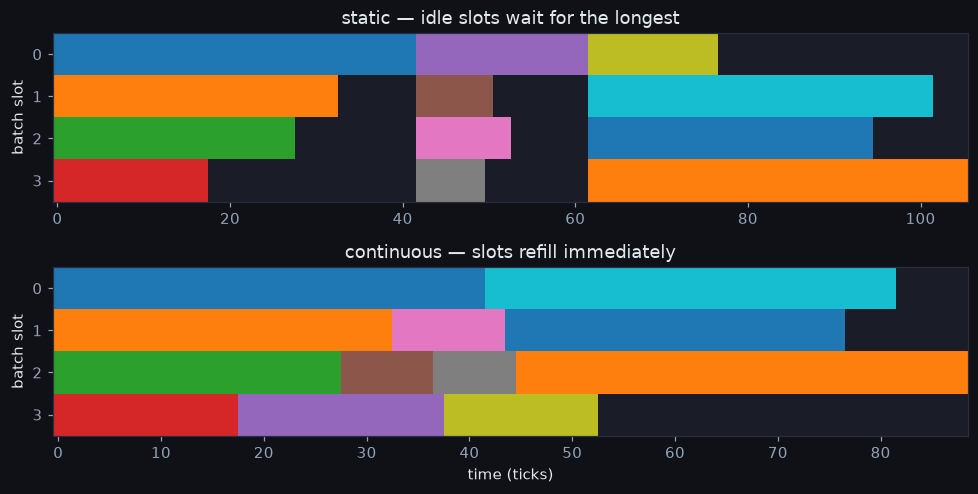

dark gaps = wasted compute


In [2]:
B = 4
occ_s = occupancy_static(gen_lens, B).T     # (B, ticks)
occ_c = occupancy_continuous(gen_lens, B).T

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6))
for ax, occ, title in ((axes[0], occ_s, "static — idle slots wait for the longest"),
                       (axes[1], occ_c, "continuous — slots refill immediately")):
    disp = np.where(occ < 0, np.nan, occ % 10)
    ax.imshow(disp, aspect="auto", cmap="tab10", vmin=0, vmax=9, interpolation="nearest")
    ax.set(title=title, ylabel="batch slot")
    ax.set_yticks(range(B))
axes[1].set_xlabel("time (ticks)")
plt.tight_layout(); plt.show()
print("dark gaps = wasted compute")

---
## 2 · Prove the output is unchanged

Scheduling changes *when* each token is computed, never *what* it is. Both schedulers must
produce exactly what each request would generate alone.


In [3]:
ok = verify_equivalence(model, reqs, B=4)
print("every request's output == standalone greedy (static AND continuous):", ok)

every request's output == standalone greedy (static AND continuous): True


---
## 3 · Measure the utilization gain

Utilization = useful decode steps ÷ occupied slot-steps. Same useful work; continuous just
wastes far fewer slots.


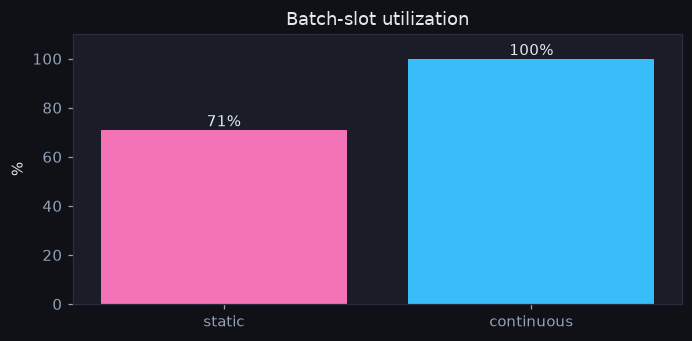

static 301/424  |  continuous 301/301  |  1.41x fewer slot-steps


In [4]:
_, s_slots, s_useful = run_static(model, reqs, B=4)
_, c_slots, c_useful = run_continuous(model, reqs, B=4)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(["static", "continuous"], [s_useful/s_slots*100, c_useful/c_slots*100],
       color=["#f472b6", "#38bdf8"])
for i, v in enumerate([s_useful/s_slots*100, c_useful/c_slots*100]):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom")
ax.set(title="Batch-slot utilization", ylabel="%"); ax.set_ylim(0, 110)
plt.tight_layout(); plt.show()
print(f"static {s_useful}/{s_slots}  |  continuous {c_useful}/{c_slots}  "
      f"|  {s_slots/c_slots:.2f}x fewer slot-steps")

---
## 4 · Where next (you've reached the real thing)

Continuous batching + the paged KV-cache from `../inference-engine` is the **core of vLLM**.
Beyond this, production engines add:
- **Chunked prefill** — interleave long prompt-processing with ongoing decodes so a big new
  prompt doesn't stall everyone.
- **Prefill/decode disaggregation** — run the compute-bound prefill and memory-bound decode on
  different hardware pools.
- **Fair scheduling / preemption** — evict and later resume sequences under memory pressure
  (paging makes this cheap).

You have now built, from scratch and provably correct, the whole path: a trained GPT, the
KV-cache, RoPE, paged attention, speculative decoding, and continuous batching — the machinery
behind an LLM serving stack.


---
## 5 · Summary

| Piece | Where | Job |
|---|---|---|
| `_Seq` | `batching.py` | one live request: its KV-cache + next logits |
| `run_static` | `batching.py` | fixed groups; run until the longest finishes |
| `run_continuous` | `batching.py` | rolling slots; refill the instant one finishes |
| `verify_equivalence` | `batching.py` | proof: batched output == standalone greedy |
| `occupancy_*` | `batching.py` | the schedule grids you visualized |

**One line:** treat the batch as rolling slots and refill them the moment a request finishes,
and utilization goes to ~100% — with byte-identical outputs.
